In [15]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import spearmanr

# Reading the data

This is the original dta I used for the MultiCAM paper.

In [16]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import spearmanr

from multicam_bolshoi.mah import get_mah
mah_data = get_mah('../data/processed/bolshoi_m12', cutoff_missing=0.05, cutoff_particle=0.05)


# extract mah of all haloes 
ma = mah_data['ma_peak']
ma.shape # the first dimension is the number of haloes, the second is the number of snapshots.

scales = mah_data['scales']
scales.shape


cat = mah_data['cat'] # astropy table with present-day halo properties
cvir = cat['cvir']
xoff = cat['x0']
t_over_u = cat['t/|u|']
spin = cat['spin_bullock']
c_to_a = cat['c_to_a']

cvir.shape, spin.shape # 1 dimensional quantities, one per halo

((10000,), (10000,))

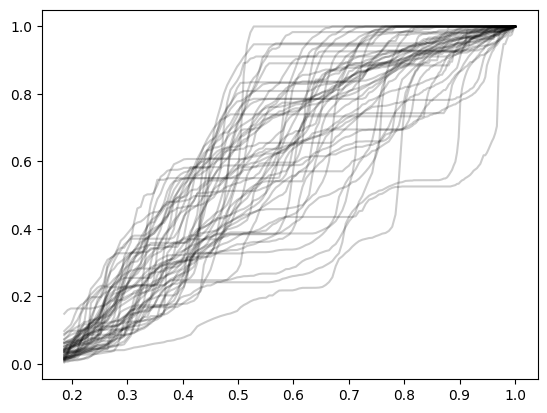

In [17]:
# MAH examples 
for _ in range(50):
    indx= np.random.randint(len(ma))
    plt.plot(scales, ma[indx], color='k', alpha=0.2)

(array([0.000e+00, 4.700e+01, 7.900e+01, 1.370e+02, 2.170e+02, 3.050e+02,
        3.960e+02, 5.480e+02, 7.530e+02, 8.640e+02, 1.004e+03, 1.093e+03,
        9.630e+02, 9.650e+02, 7.620e+02, 5.860e+02, 4.090e+02, 2.930e+02,
        2.090e+02, 1.030e+02, 8.300e+01, 3.600e+01, 2.600e+01, 2.600e+01,
        1.300e+01, 1.200e+01, 1.200e+01, 9.000e+00, 5.000e+00, 8.000e+00,
        5.000e+00, 1.000e+00, 2.000e+00, 3.000e+00, 1.000e+00, 1.000e+00,
        2.000e+00, 2.000e+00, 3.000e+00, 3.000e+00, 1.000e+00, 1.000e+00,
        1.000e+00, 2.000e+00, 0.000e+00, 1.000e+00, 2.000e+00, 1.000e+00,
        1.000e+00, 1.000e+00, 0.000e+00]),
 array([ 0.        ,  0.78431373,  1.56862745,  2.35294118,  3.1372549 ,
         3.92156863,  4.70588235,  5.49019608,  6.2745098 ,  7.05882353,
         7.84313725,  8.62745098,  9.41176471, 10.19607843, 10.98039216,
        11.76470588, 12.54901961, 13.33333333, 14.11764706, 14.90196078,
        15.68627451, 16.47058824, 17.25490196, 18.03921569, 18.82352941,


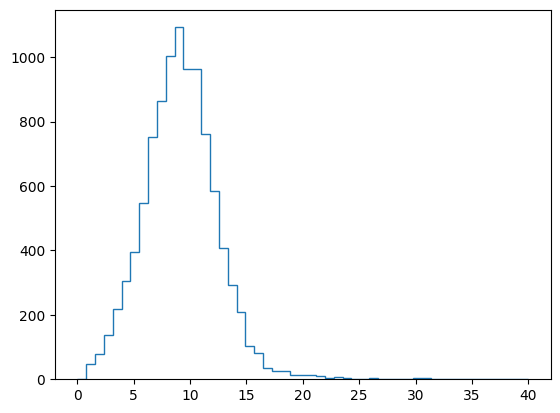

In [18]:
# concentration histogram 
plt.hist(cvir, bins=51, histtype='step', range=(0, 40))

# Algorithms

In [37]:
def _create_rank_lookup(x):
    assert x.ndim == 2
    n_features = x.shape[1]
    rank_lookup = {} 

    # lookup table of ranks 
    for jj in range(n_features):
        xjj = np.sort(x[:, jj])
        u, c = np.unique(xjj, return_counts=True)
        lranks = np.cumsum(c) - c + 1
        hranks = np.cumsum(c)
        rank_lookup[jj] = (u, lranks, hranks)

    return rank_lookup

def _get_test_ranks(x, x_train, rank_lookup, mode="middle"):
    assert mode in {"middle", "random"}
    assert x.ndim == 2 
    n_features = x.shape[1]

    # get ranks of test data (based on training data)
    xr = np.zeros_like(x) * np.nan
    for jj in range(n_features):
        x_jj = x[:, jj]
        x_train_jj = np.sort(x_train[:, jj])
        uniq, lranks, hranks = rank_lookup[jj]
        xr[:, jj] = np.searchsorted(x_train_jj, x_jj) + 1  # indices to ranks

        # if value is in training data, get middle or random rank
        in_train = np.isin(x_jj, uniq)
        u_indices = np.searchsorted(uniq, x_jj[in_train])
        lr, hr = lranks[u_indices], hranks[u_indices]  # repeat appropriately
        xr[in_train, jj] = (
            np.random.randint(lr, hr + 1) if mode == "random" else (lr + hr) / 2
        )

    assert np.sum(np.isnan(xr)) == 0

    return xr


def _value_at_rank(x, ranks):
    """Get value at ranks of multidimensional array."""
    assert x.shape[1] == ranks.shape[1]
    assert ranks.dtype == int
    n, m = ranks.shape
    y = np.zeros((n, m), dtype=float)
    for ii in range(m):
        y[:, ii] = np.take(x[:, ii], ranks[:, ii])
    return y



In [38]:
from sklearn.preprocessing import QuantileTransformer
from sklearn import linear_model
from scipy.stats import rankdata


def _gauss_transform(x: np.ndarray):
    """Transform x to be (marginally) gaussian."""
    assert x.ndim == 2
    qt = QuantileTransformer(n_quantiles=len(x), output_distribution="normal", subsample=None)
    qt.fit(x)
    return qt.transform(x), qt

def multicam(x, x_train, y_train):
    assert x.ndim == x_train.ndim == y_train.ndim == 2
    
    # ranks
    xrt = rankdata(x_train, axis=0, method='ordinal')
    yrt = rankdata(y_train, axis=0, method='ordinal')

    # gaussianized ranks
    xgt, qtx = _gauss_transform(xrt)
    ygt, qty = _gauss_transform(yrt)

    # fit linear model 
    reg = linear_model.LinearRegression()
    reg.fit(xgt, ygt)

    # qt to gaussianize output of linear model 
    ypt = reg.predict(xgt)
    _, qtp = _gauss_transform(ypt)

    # create rank lookup
    rank_lookup = _create_rank_lookup(x_train)

    # rankify and gaussianize the test x based on x_train
    xr = _get_test_ranks(x, x_train, rank_lookup, mode='middle')
    xg = qtx.transform(xr)

    # predict on transformed ranks 
    yng = reg.predict(xg)

    # gaussianize yng based on train y
    yg = qtp.transform(yng)
    yr = qty.inverse_transform(yg).astype(int)

    # predictions are points in train data corresponding to ranks predicted
    y_train_sorted = np.sort(y_train, axis=0)
    yp = _value_at_rank(y_train_sorted, yr - 1)
    return yp, yg, yng, xg

In [54]:
from scipy.stats import norm, rankdata

def qt_uniform(x, axis: int = 0, method="ordinal"):  # default in rankdata = 'average'
    """Transform array to a uniform distribution based on ranks."""
    ranks = rankdata(x, axis=axis, method=method)
    return ranks / (ranks.shape[axis] + 1)  # excludes 0 and 1


def qt_gauss(x, axis: int = 0, method="ordinal"):
    """Transform array to a Gaussian distribution based on ranks."""
    u = qt_uniform(x, axis=axis, method=method)
    return norm.ppf(u)


def qt_gauss_base(x, x_base):
    """Gaussinize input based on another dataset."""
    # always assume second dimension is n_features.
    assert x.ndim == 2 and x_base.ndim == 2
    assert x.shape[1] == x_base.shape[1]
    n_features = x.shape[1]
    x_gauss = np.zeros_like(x) * np.nan
    for jj in range(n_features):
        x_jj = x[:, jj]
        xb_jj = np.sort(x_base[:, jj])  # required for np.interp
        xb_gauss_jj = qt_gauss(xb_jj, method="ordinal")
        x_gauss[:, jj] = np.interp(x_jj, xb_jj, xb_gauss_jj)
    return x_gauss


def qt_inverse_gauss_base(x_gauss, x_base):
    assert x_gauss.ndim == 2 and x_base.ndim == 2
    assert x_gauss.shape[1] == x_base.shape[1]
    n_features = x_gauss.shape[1]
    x_out = np.zeros_like(x_gauss) * np.nan
    for jj in range(n_features):
        xg_jj = x_gauss[:, jj]
        xb_jj = np.sort(x_base[:, jj])  # required for np.interp
        xb_gauss_jj = qt_gauss(xb_jj, method="ordinal")
        x_out[:, jj] = np.interp(xg_jj, xb_gauss_jj, xb_jj)
    return x_out

def new_multicam(x, x_train, y_train):
    assert x.ndim == x_train.ndim == y_train.ndim == 2

    # ranks are unnecessary to start as qt_gauss already uses 'ordinal'
    # the one that we have to be careful with is `qt_gauss_base` below
    xgt = qt_gauss(x_train, axis=0)
    ygt = qt_gauss(y_train, axis=0)

    reg = linear_model.LinearRegression()
    reg.fit(xgt, ygt)

    rank_lookup = _create_rank_lookup(x_train)

    xr = _get_test_ranks(x, x_train, rank_lookup, mode='middle')
    xrt = rankdata(x_train, axis=0, method='ordinal')
    xg = qt_gauss_base(xr, xrt)
    
    yng = reg.predict(xg)

    yngt = reg.predict(xgt)
    yg = qt_gauss_base(yng, yngt)

    # invert y_gauss to data space based on gaussianized y_train.
    yp = qt_inverse_gauss_base(yg, y_train) 
    return yp, yg,  yng, xg


# Testing

In [55]:
from multicam.train import _get_tt_indices

n_haloes = len(cat)
train_idx, test_idx = _get_tt_indices(n_haloes, test_ratio=0.25)

In [56]:
ma_train = ma[train_idx][:, :]
ma_test = ma[test_idx][:, :]
cvir_train = cvir[train_idx].reshape(-1, 1)
cvir_test = cvir[test_idx].reshape(-1, 1)
ma_train.shape, cvir_train.shape

((7500, 165), (7500, 1))

In [57]:
yp1, yg1, yng1, xg1 = multicam(ma_test, ma_train, cvir_train)

In [58]:
spearmanr(yp1, cvir_test)

SignificanceResult(statistic=np.float64(0.7850524829108034), pvalue=np.float64(0.0))

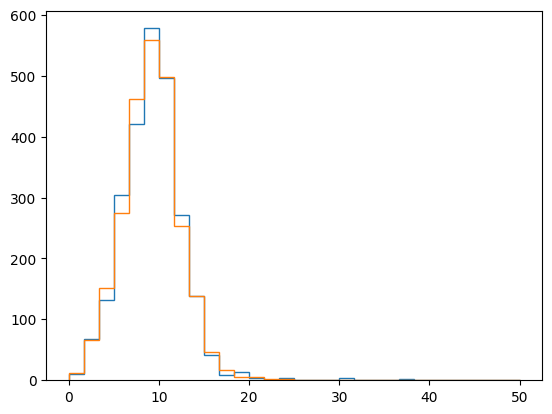

In [59]:
bins = np.linspace(0, 50, 31)
plt.hist(yp1, bins=bins, histtype='step')
plt.hist(cvir_test, bins=bins, histtype='step');

In [60]:
yp2, yg2, yng2, xg2 = new_multicam(ma_test, ma_train, cvir_train)

In [63]:
spearmanr(yp2, cvir_test)

SignificanceResult(statistic=np.float64(0.7861994136458068), pvalue=np.float64(0.0))

In [64]:
yp2.min()

np.float64(1.0144979967788625)

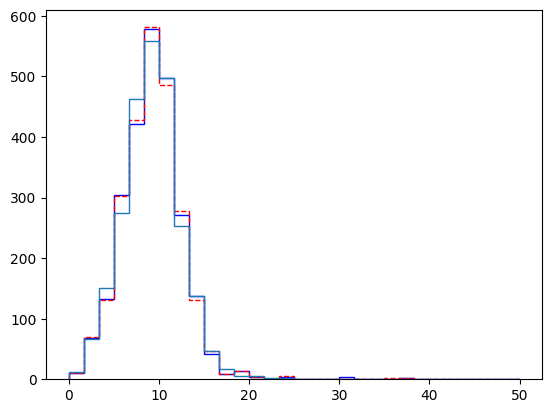

In [67]:
bins = np.linspace(0, 50, 31)
plt.hist(yp1, bins=bins, histtype='step', color='b')
plt.hist(yp2, bins=bins, histtype='step', ls='--', color='r')
plt.hist(cvir_test, bins=bins, histtype='step');